         ts_s  loss_rate
0  1632344359   0.000000
1  1632344360   0.000000
2  1632344361   0.115942
3  1632344362   0.062500
4  1632344363   0.050000


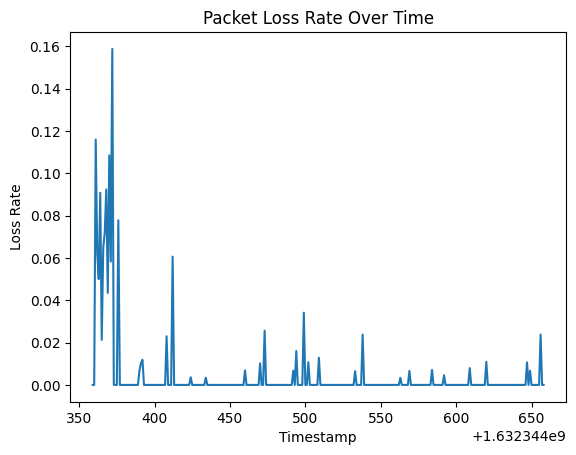

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv("statsnew.csv")

# Compute loss rate: lost / (pkts + lost)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"])


# 

# Group by timestamp and compute average loss rate
loss_rate_per_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

print(loss_rate_per_time.head())


loss_rate_per_time.to_csv("loss_rate_per_time.csv", index=False)

# Plot (optional)
import matplotlib.pyplot as plt
plt.plot(loss_rate_per_time["ts_s"], loss_rate_per_time["loss_rate"])
plt.xlabel("Timestamp")
plt.ylabel("Loss Rate")
plt.title("Packet Loss Rate Over Time")
plt.show()

This will:

Read the stats file

Calculate the loss rate per row

Aggregate (average) per timestamp

Save results to loss_rate_per_time.csv

Plot a simple time vs loss rate curve

 Flows.csv shows aggregate info: how many packets/bytes each flow carried, when it started, and when it ended.It has 2 rows, each representing one UDP flow. Columns:

flow_id → identifier for each flow.

ip_proto → protocol (17 = UDP).

ip_src / tp_src → source IP and port.

ip_dst / tp_dst → destination IP and port.

type → udp_srv (UDP service flow).

pkts / bytes → total packets and bytes observed for the flow.

start_ts_tvs / start_ts_tvus → start time of the flow (seconds + microseconds).

end_ts_tvs / end_ts_tvus → end time of the flow (seconds + microseconds).

UNIQUE.csv this generates unique RTP stream details (SSRC, zoom type, codec-level packet counts): It has 2 rows (so 2 unique RTP/UDP streams) and these columns:

stream_id → identifier for the stream.

conn_type → type of connection (udp_srv).

start_ts_s / end_ts_s → start and end timestamps (in seconds).

ip_src / tp_src, ip_dst / tp_dst → source and destination IP/port.

zoom_type → likely internal classification (e.g., audio = 15, video = 16).

ssrc → RTP SSRC (unique identifier for RTP stream).

start_rtp_ts / end_rtp_ts → RTP timestamps at start and end of capture.

pkts / bytes → total packets and bytes in the stream.

audio_112_pkts / audio_99_pkts / audio_113_pkts → per-codec packet counts (probably different Opus payload types or RTP payload IDs used by Zoom).

unique.csv = deduplicated stream table, one row per unique RTP stream.

It captures lifetime, identifiers, and packet breakdowns (even distinguishing audio codec types).

TYPES.csv file is a traffic classification summary.

It has 8 rows, each describing a traffic category, with these columns:

mode → here always srv, likely meaning “server-side flow”.

outer_type → high-level protocol/type identifier (5 in all rows, probably UDP/RTP).

inner_type → sub-type (e.g., 1.0, 15.0, 16.0, 21.0, 32.0). These likely correspond to RTP payload types or Zoom’s internal stream categories (e.g., audio vs video vs control).

pkts → total packets observed for that type.

bytes → total bytes observed for that type.